In [26]:
import os, pandas as pd, numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, sys

In [27]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [28]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [29]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/selected_data.csv")

# 데이터 상태 확인

In [30]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 65 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mix_temp_c                    12960 non-null  float64
 1   bearing_temperature_c         12960 non-null  float64
 2   acid_tank_level_pct           12960 non-null  float64
 3   mix_ph                        12960 non-null  float64
 4   motor_power_kw                12960 non-null  float64
 5   zone2_substrate_ec_ds_m       12960 non-null  float64
 6   motor_temperature_c           12960 non-null  float64
 7   valve_acid_on                 12960 non-null  int64  
 8   acoustic_db                   12960 non-null  float64
 9   zone1_flow_l_min              613 non-null    float64
 10  zone3_substrate_ph            12960 non-null  float64
 11  timestamp                     12960 non-null  object 
 12  drainage_ratio_pct            12960 non-null  float64
 13  z

In [31]:
df_raw.describe()

,mix_temp_c,bearing_temperature_c,acid_tank_level_pct,mix_ph,motor_power_kw,zone2_substrate_ec_ds_m,motor_temperature_c,valve_acid_on,acoustic_db,zone1_flow_l_min,...,vibration_bandpower_high,mix_flow_l_min,turbidity_ntu,relative_humidity_pct,drain_ec_ds_m,zone2_pressure_kpa,vpd_kpa,dehumidifier_state,lights_on,suction_pressure_kpa
count,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,613.000000,...,12960.000000,12960.000000,12960.000000,12960.000000,12960.000000,615.000000,12960.000000,12960.000000,12960.000000,12960.000000
mean,17.368159,27.100143,79.454931,5.980143,0.115243,1.849516,24.118238,0.103549,46.776328,10.314454,...,0.459151,1.450643,0.289652,69.026258,1.812074,79.009987,0.769293,0.393519,0.583333,110.046319
std,1.271317,2.180459,2.231690,0.013926,0.108991,0.048361,1.426114,0.304687,6.865823,9.964425,...,0.135290,5.414579,0.294527,11.032093,0.035367,51.292972,0.485451,0.488549,0.493026,5.967475
min,15.622000,24.366000,75.500000,5.930400,0.011110,1.734800,22.356000,0.000000,39.743000,0.000000,...,0.270900,0.000000,0.000000,50.598000,1.679800,0.000000,0.118700,0.000000,0.000000,103.444000
25%,15.858000,24.607000,78.000000,5.971000,0.016260,1.813000,22.563000,0.000000,40.006000,0.993000,...,0.365500,0.000000,0.000000,59.482750,1.791800,34.598500,0.203000,0.000000,0.000000,104.013000
50%,18.161000,27.152500,78.700000,5.980500,0.114015,1.851100,24.349000,0.000000,46.755500,7.932000,...,0.389500,0.000000,0.061050,61.809500,1.806900,77.563000,1.055350,0.000000,1.000000,110.901500
75%,18.559000,28.000000,80.900000,5.989400,0.183463,1.881700,25.436000,0.000000,52.530000,16.061000,...,0.635925,0.000000,0.581900,81.793000,1.822700,121.063500,1.199800,1.000000,1.000000,116.072000
max,18.978000,32.700000,84.100000,6.064500,0.501270,2.006000,27.017000,1.000000,61.995000,38.725000,...,0.758100,40.956000,0.725000,89.188000,1.975500,179.684000,1.643300,1.000000,1.000000,117.089000


In [32]:
cat_cols = ["pump_on",
"lights_on",
"ventilation_state",
"dehumidifier_state",
"valve_a_on",
"valve_b_on",
"valve_acid_on",
"zone1_valve_on",
"zone2_valve_on",
"zone3_valve_on"]

#### 데이터 형 변환

In [33]:
# ON은 True로, OFF는 False로 변환
bool_map = {'ON': True, 'OFF': False, '1': True, '0': False, 1: True, 0: False}

for col in cat_cols:
    df_raw[col] = df_raw[col].map(bool_map)

# 결과 확인
print(df_raw[cat_cols].dtypes)

pump_on               bool
lights_on             bool
ventilation_state     bool
dehumidifier_state    bool
valve_a_on            bool
valve_b_on            bool
valve_acid_on         bool
zone1_valve_on        bool
zone2_valve_on        bool
zone3_valve_on        bool
dtype: object


In [34]:
# 타임스탬프 데이터타입으로 변환
df_raw["timestamp"] = pd.to_datetime(df_raw['timestamp'])

In [35]:
# 'id' 컬럼을 인덱스(PK 역할)로 설정
df_raw = df_raw.set_index('timestamp')

# 결측치 확인 

In [36]:
df_raw[df_raw.isnull()].count()

mix_temp_c               0
bearing_temperature_c    0
acid_tank_level_pct      0
mix_ph                   0
motor_power_kw           0
                        ..
zone2_pressure_kpa       0
vpd_kpa                  0
dehumidifier_state       0
lights_on                0
suction_pressure_kpa     0
Length: 64, dtype: int64

In [37]:
df_raw[df_raw.isnull()].count().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

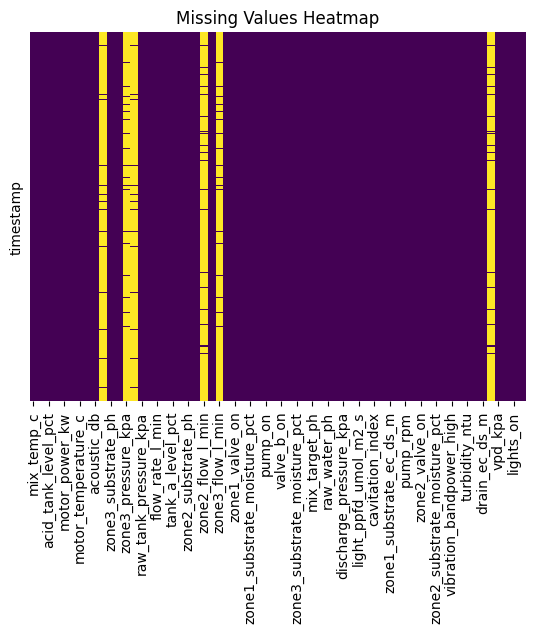

In [38]:
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

# 데이터 상관관계 확인

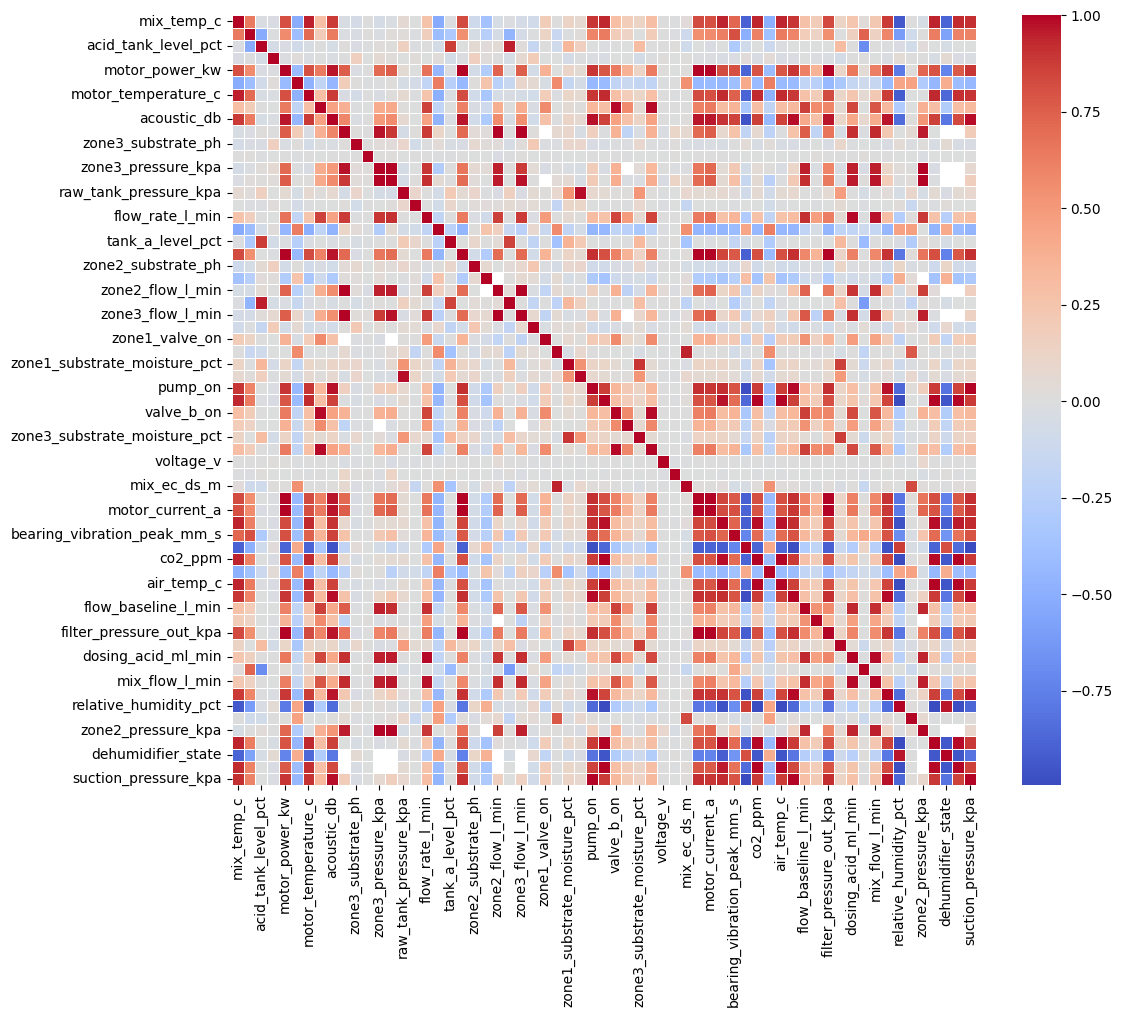

In [39]:
# 상관계수 계산
corr = df_raw.corr(numeric_only=True)

# 특정 기준(예: 상관계수 0.5) 이상의 관계가 하나라도 있는 컬럼만 추출
threshold = 0.5
high_corr_cols = corr.columns[(corr.abs() > threshold).any()]
filtered_corr = corr.loc[high_corr_cols, high_corr_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.show()

In [40]:
# 2. 전체 상관계수 계산 (숫자형 + 수치화된 범주형)
corr_matrix = df_raw.corr(numeric_only=True).abs()

# 3. 상삼각 행렬만 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [41]:
threshold = 0.7
high_corr_pairs = np.where(upper > threshold)

# 쌍(Pair) 리스트 생성
pairs = [(upper.index[i], upper.columns[j], upper.iloc[i, j]) 
        for i, j in zip(*high_corr_pairs)]

# 그룹화 (Dictionary 활용)
groups = {}
for p1, p2, val in pairs:
    if p1 not in groups: groups[p1] = []
    groups[p1].append(f"{p2}({val:.2f})")

print(f"--- [상관계수 {threshold} 이상] 연관 변수 그룹 ---")
if not groups:
    print("기준치를 넘는 고상관 변수가 없습니다.")
else:
    for key, values in groups.items():
        print(f"[{key}] 변수와 중복 위험: {', '.join(values)}\n")

--- [상관계수 0.7 이상] 연관 변수 그룹 ---
[mix_temp_c] 변수와 중복 위험: motor_power_kw(0.81), motor_temperature_c(0.95), acoustic_db(0.88), filter_pressure_in_kpa(0.83), pump_on(0.90), raw_water_temp_c(0.94), discharge_pressure_kpa(0.83), motor_current_a(0.81), light_ppfd_umol_m2_s(0.94), bearing_vibration_peak_mm_s(0.72), cavitation_index(0.90), co2_ppm(0.94), air_temp_c(0.94), pump_rpm(0.89), filter_pressure_out_kpa(0.83), turbidity_ntu(0.88), relative_humidity_pct(0.94), vpd_kpa(0.95), dehumidifier_state(0.89), lights_on(0.92), suction_pressure_kpa(0.91)

[bearing_temperature_c] 변수와 중복 위험: motor_temperature_c(0.71), bearing_vibration_peak_mm_s(0.81), vibration_bandpower_high(0.74)

[acid_tank_level_pct] 변수와 중복 위험: tank_a_level_pct(0.87), tank_b_level_pct(0.95)

[motor_power_kw] 변수와 중복 위험: motor_temperature_c(0.81), acoustic_db(0.96), zone1_flow_l_min(0.76), zone3_pressure_kpa(0.72), zone1_pressure_kpa(0.76), filter_pressure_in_kpa(1.00), zone2_flow_l_min(0.74), zone3_flow_l_min(0.75), pump_on(0.90),

In [42]:
compare_groups = {
    "Flow Rate Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_flow_l_min", "zone2_flow_l_min", "zone3_flow_l_min"
    ],
    "Pressure Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_pressure_kpa", "zone2_pressure_kpa", "zone3_pressure_kpa"
    ],
    "pH Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ph", "mix_ph", "zone1_substrate_ph", "zone2_substrate_ph", "zone3_substrate_ph"
    ],
    "EC Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ec_ds_m", "mix_ec_ds_m", "zone1_substrate_ec_ds_m", "zone2_substrate_ec_ds_m", "zone3_substrate_ec_ds_m"
    ],
    "Temperature Comparison": [
        "air_temp_c", "mix_temp_c", "raw_water_temp_c", "motor_temperature_c"
    ],
    "Tank Levels": [
        "raw_tank_level_pct", "tank_a_level_pct", "tank_b_level_pct", "acid_tank_level_pct"
    ],
    "Tank_pressure": [
        "filter_pressure_in_kpa", "filter_pressure_out_kpa","suction_pressure_kpa","discharge_pressure_kpa"
    ]

}

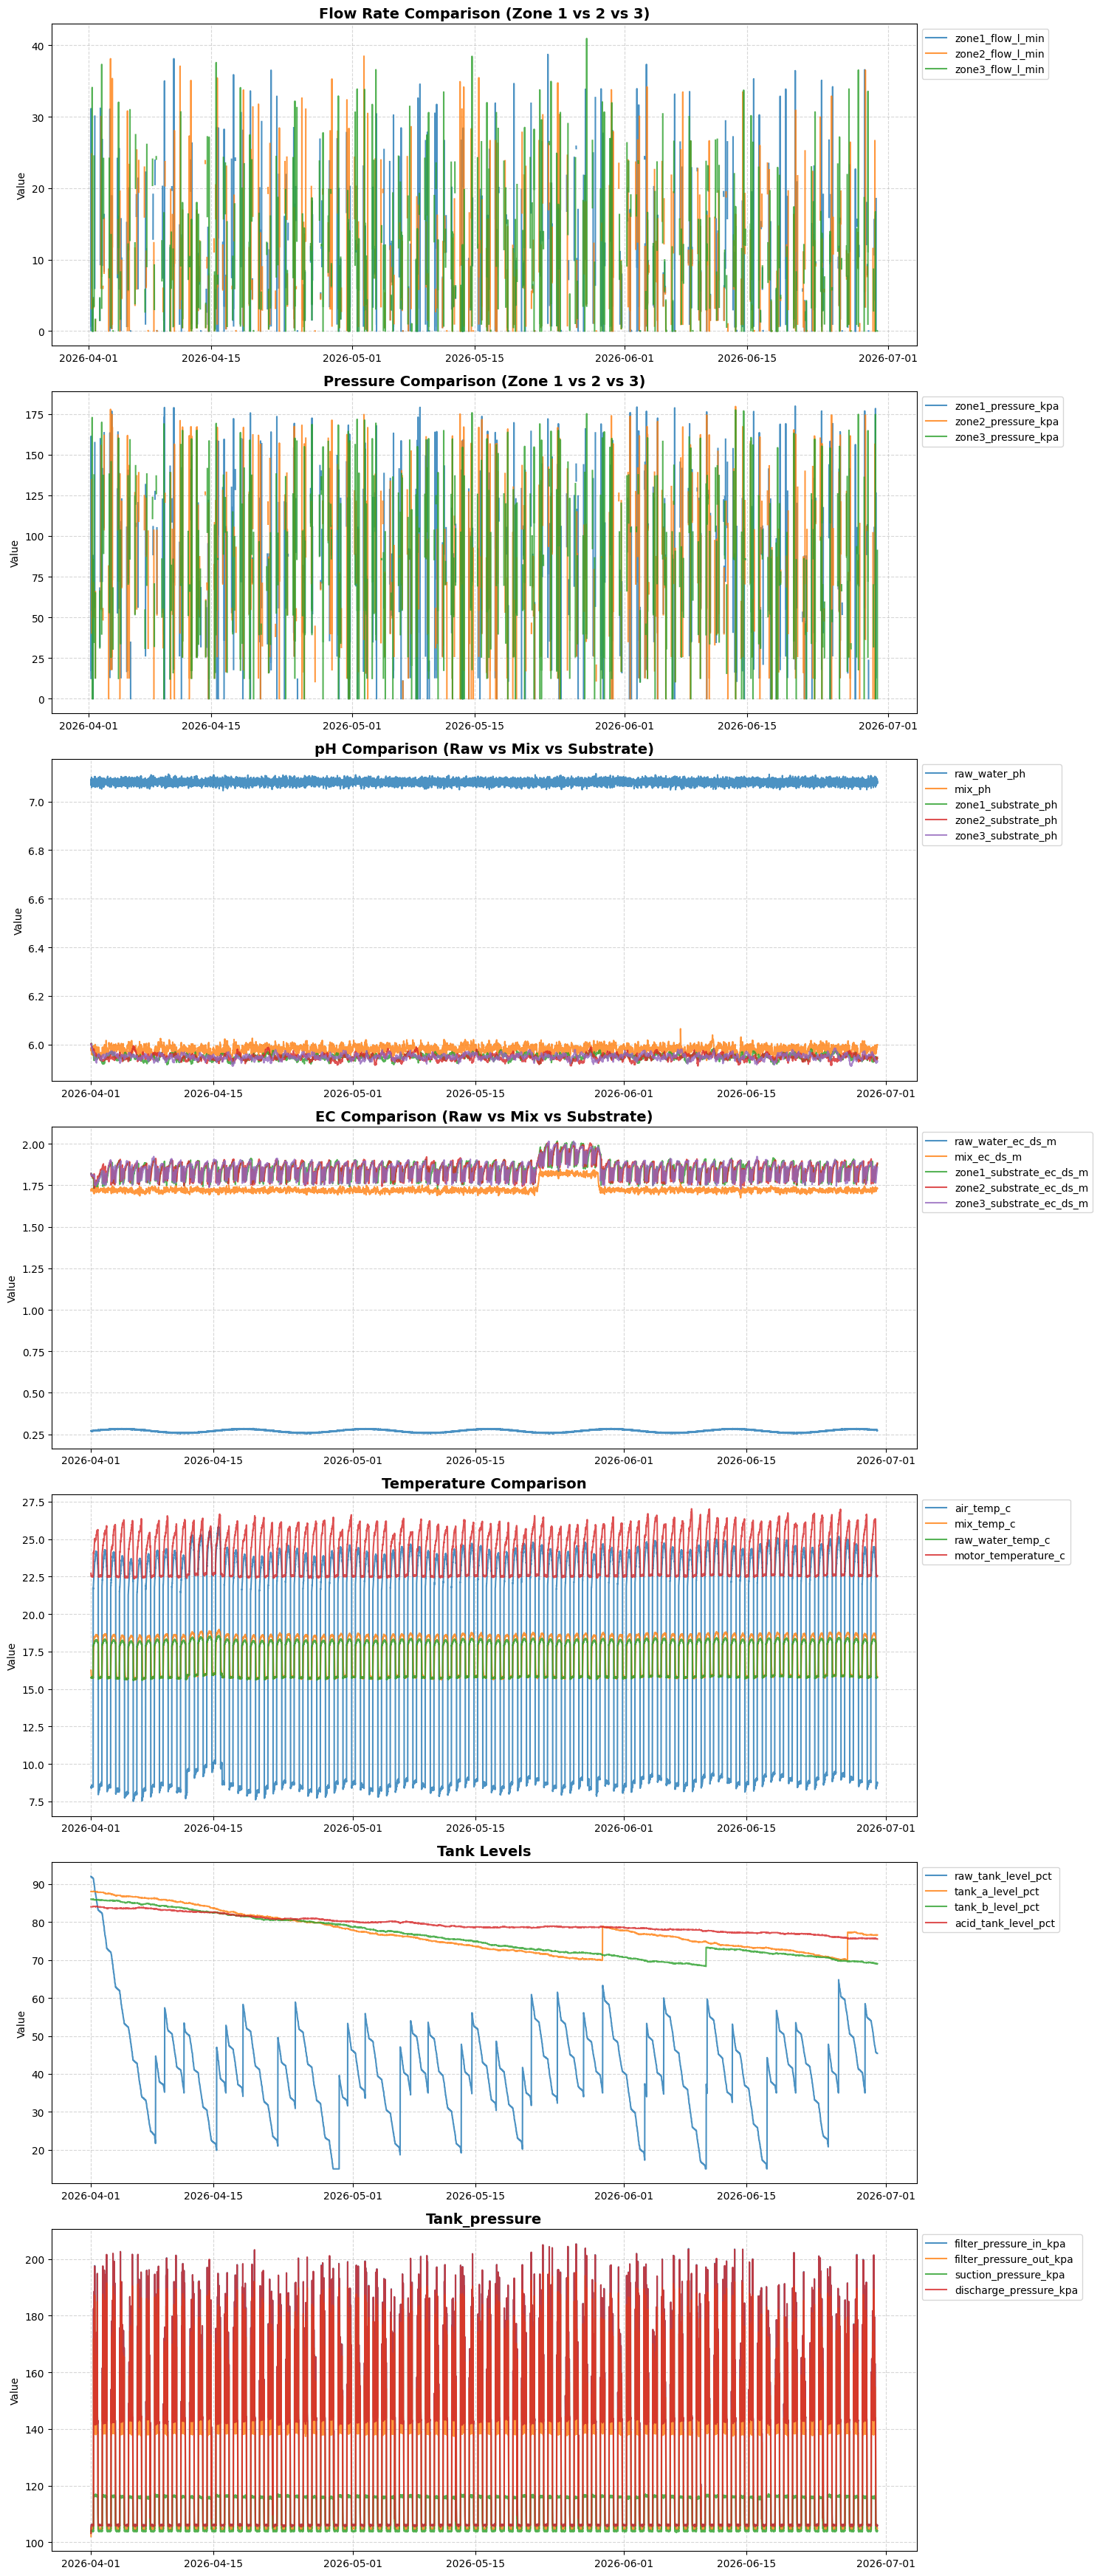

In [ ]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
# 10분 간격, 60분, 24시간 이니까  = 6*24
plot_df = df_raw.iloc[:] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

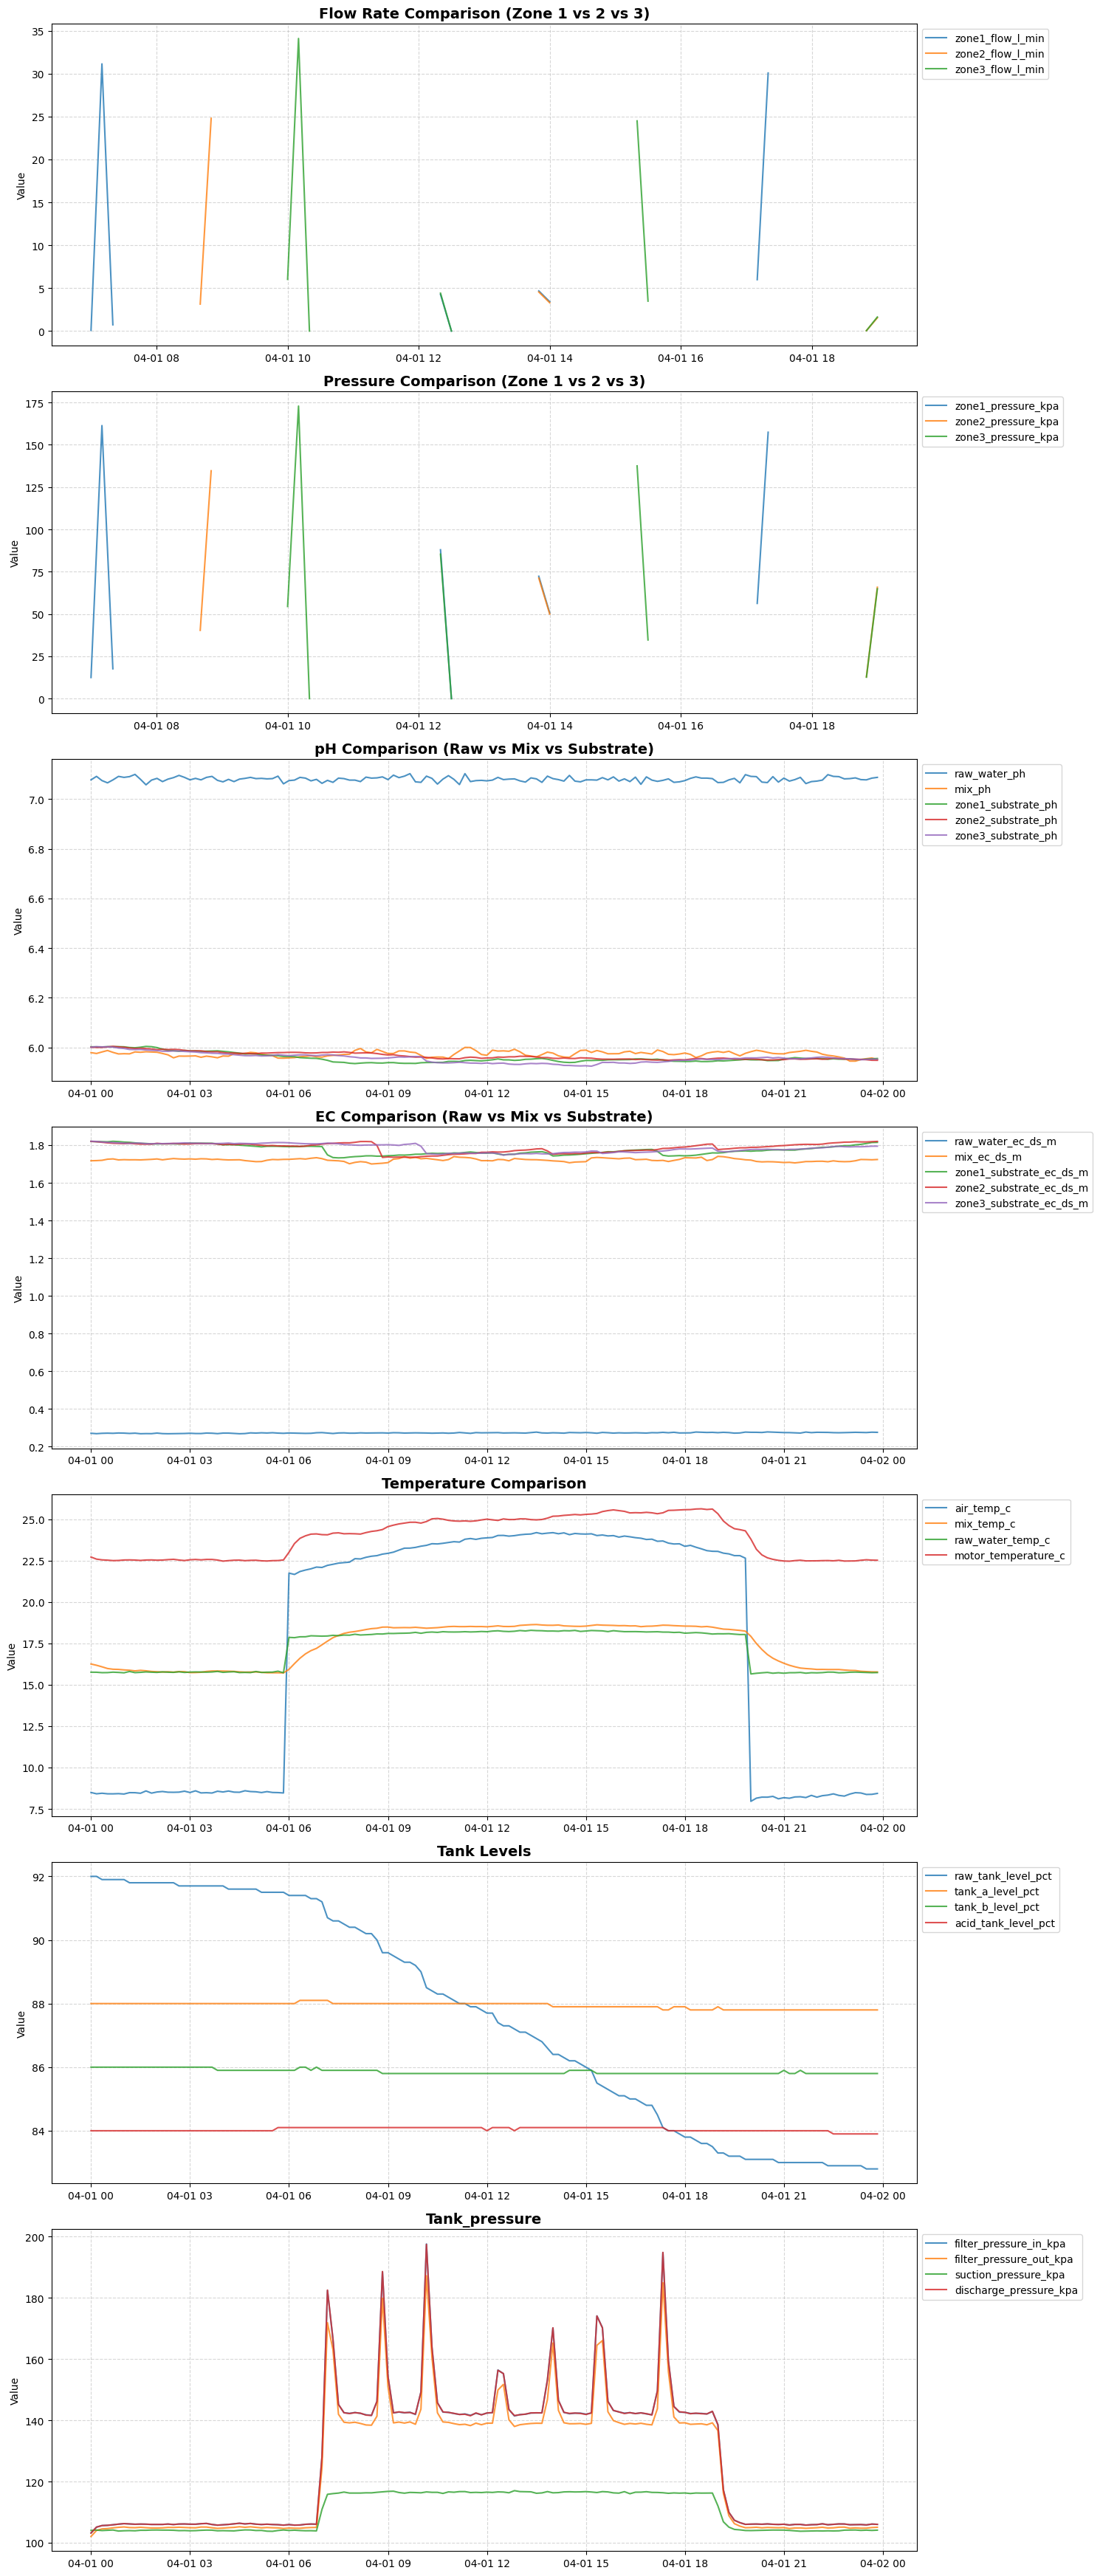

In [46]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


minute_per_day = 6*24

# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

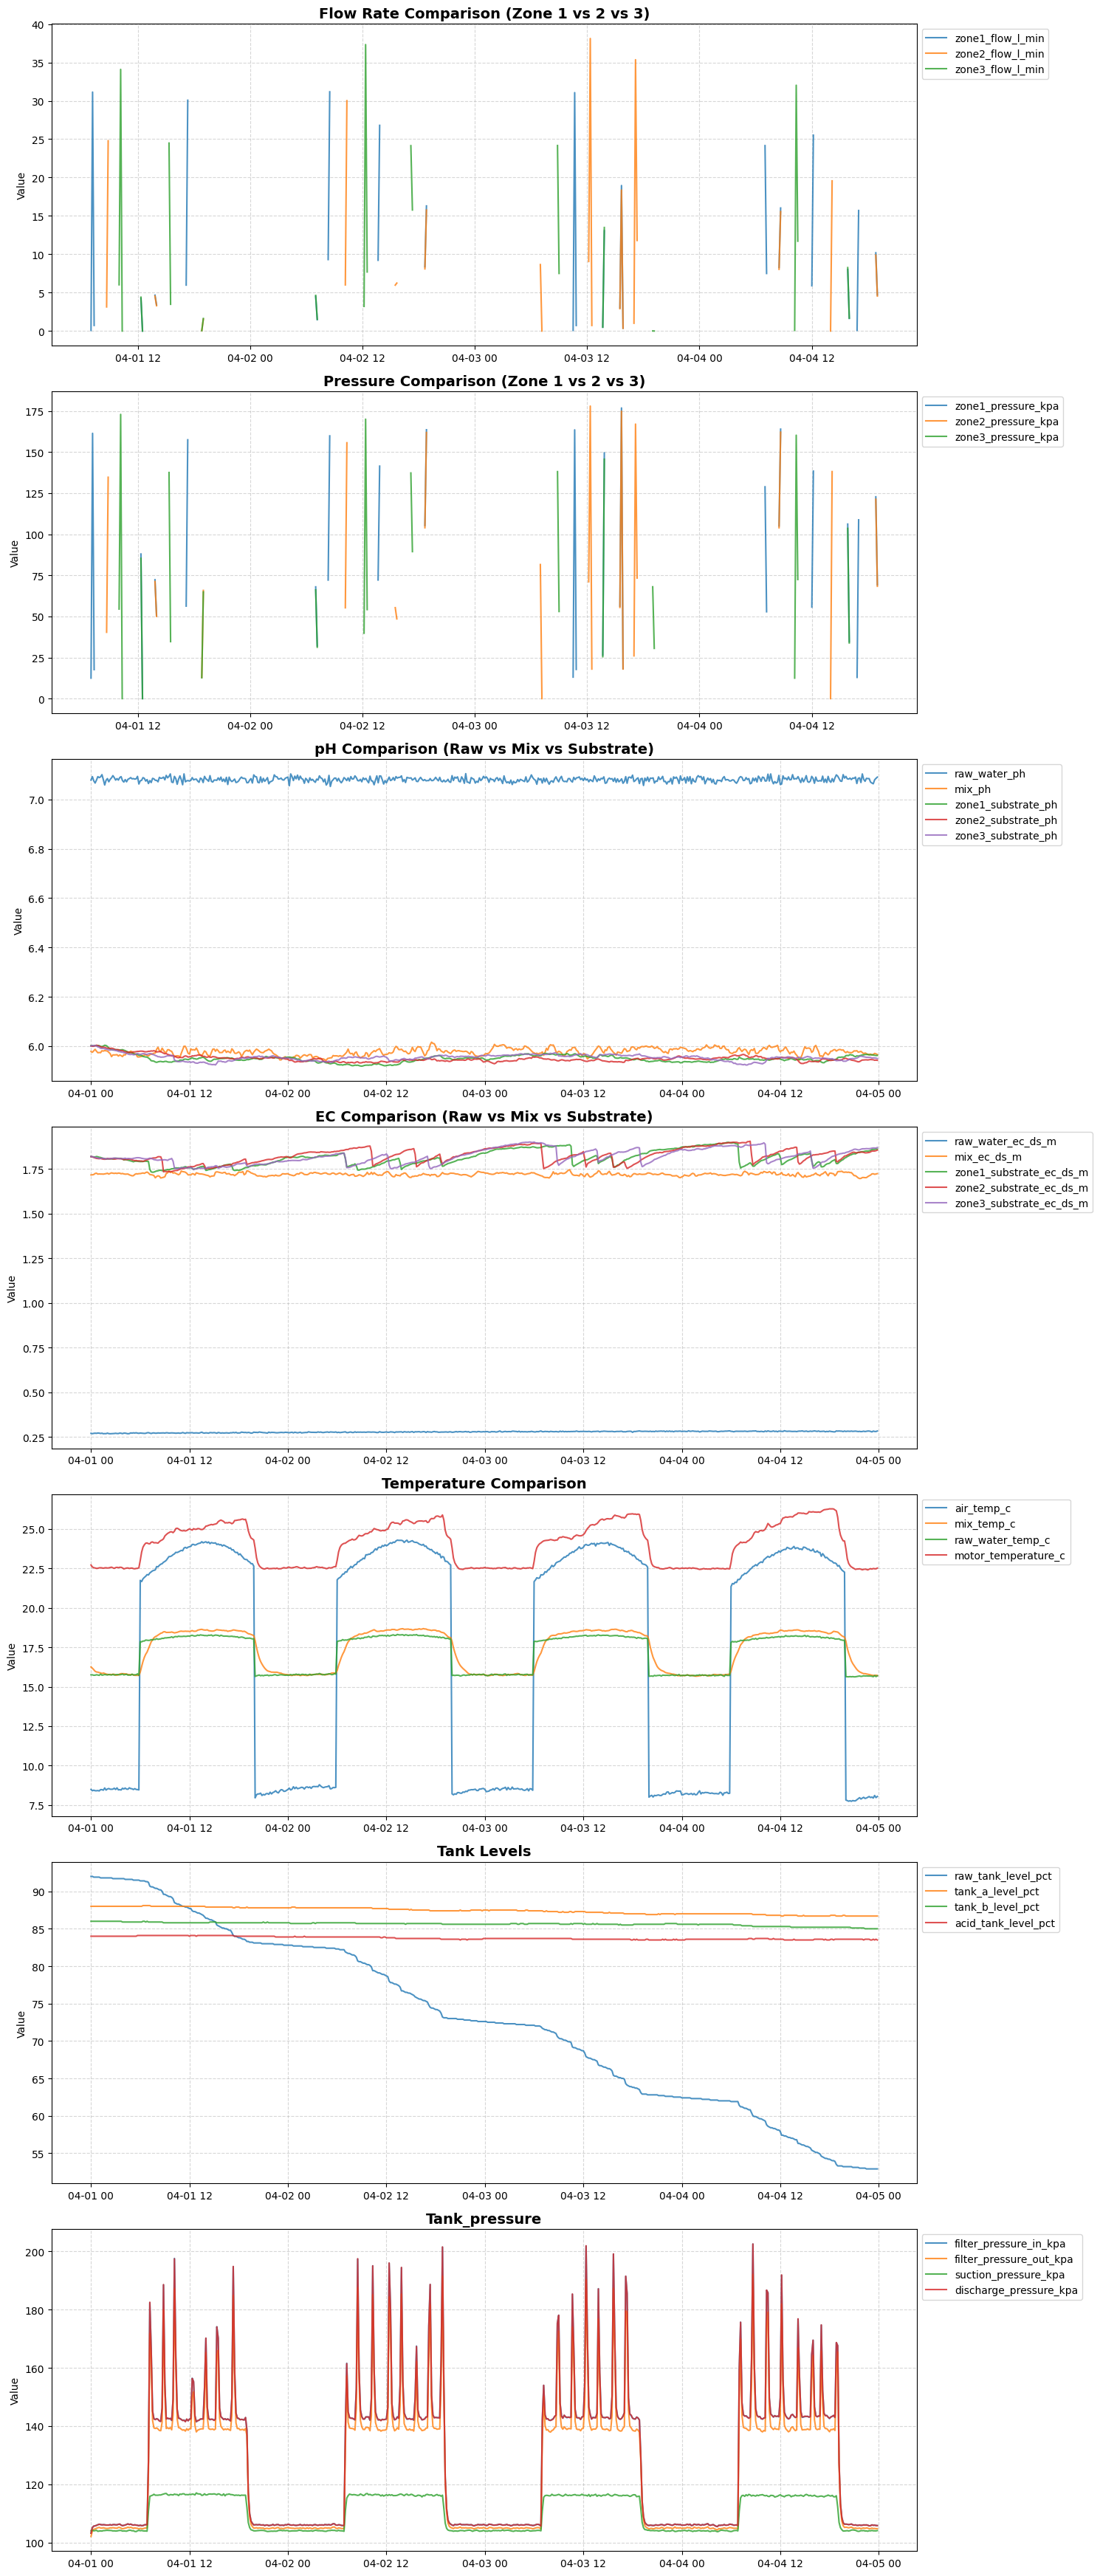

In [48]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))

minute_per_day = 6*24*2

# 이틀 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day*2] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

문제 사항 1 : 지금 밤(딸기 기준)에 유량, 탱크 압력, 모터 온도 등을 보았을 때, 양액이 나가는 걸로 판단되는데, 왜 Zone2, Zone3는 왜 유속이 안 뜨냐?

- 데이터 생성 중 로직 꼬여서 생긴 문제로 판명. 원래는 뿌려주면 안 됨.
- WHY (중요성): 밤에는 식물이 광합성을 멈추고 호흡만 합니다. 이때 뿌리에 물이 너무 많으면 산소가 부족해져 뿌리가 썩는 '습해'가 발생하거나, 증산 작용이 없는 상태에서 세포 내 압력(근압)만 높아져 과실이 터지거나 곰팡이병이 발생할 위험이 큽니다.
  - 새로운 데이터 요청 완료.

# 파생변수 생성

In [23]:
df_copy = df_raw.copy()

In [25]:
df_copy.columns

Index(['tank_b_level_pct', 'zone3_substrate_ec_ds_m', 'zone3_substrate_ph',
       'zone2_substrate_ph', 'filter_pressure_in_kpa', 'motor_power_kw',
       'mix_target_ec_ds_m', 'zone3_pressure_kpa', 'air_temp_c',
       'drainage_ratio_pct', 'filter_pressure_out_kpa', 'cavitation_index',
       'vibration_bandpower_high', 'turbidity_ntu', 'dosing_acid_ml_min',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'flow_rate_l_min', 'valve_a_on', 'raw_water_ph', 'motor_current_a',
       'zone2_substrate_ec_ds_m', 'flow_baseline_l_min', 'zone2_pressure_kpa',
       'vpd_kpa', 'drain_ec_ds_m', 'mix_ec_ds_m', 'valve_acid_on', 'lights_on',
       'dehumidifier_state', 'co2_ppm', 'raw_water_ec_ds_m', 'zone3_valve_on',
       'mix_target_ph', 'discharge_pressure_kpa', 'bearing_temperature_c',
       'zone1_flow_l_min', 'motor_temperature_c', 'mix_flow_l_min', 'pump_on',
       'mix_ph', 'mix_temp_c', 'raw_tank_level_pct', 'tank_a_level_pct',
       'relative_humidity_pct'

In [ ]:
"""
다중공선성에 매우 강합니다. 비슷한 컬럼(예: 온도와 습도, 타겟 EC와 실제 EC)이 들어와도 알아서 분기점(Split)을 찾으며, 모델 성능이 무너지지 않습니다.

따라서 무작정 VIF로 날리기보다는, 트리 모델을 한 번 돌려보고 Feature Importance(변수 중요도)나 SHAP Value를 뽑아본 뒤, 예측에 전혀 기여하지 않는 깡통 변수들을 쳐내는(Pruning) 방식이 훨씬 안전하고 성능이 좋습니다
"""

# 1. 컬럼들을 성격에 맞게 리스트로 분류합니다.
dynamic_cols = ['discharge_pressure_kpa', 'suction_pressure_kpa', 'flow_rate_l_min', 
                'motor_current_a', 'bearing_vibration_rms_mm_s'] # 동특성 필요
slow_cols = ['air_temp_c', 'relative_humidity_pct', 'mix_ec_ds_m', 
            'zone1_substrate_moisture_pct', 'raw_tank_level_pct'] # 평균만 필요
state_cols = ['pump_on', 'zone1_valve_on'] # 상태 (Max)

# 2. agg에 전달할 딕셔너리를 동적으로 생성합니다.
agg_dict = {}

for col in dynamic_cols:
    agg_dict[col] = ['mean', 'std'] # 압력, 유량 등은 평균과 편차 모두!

for col in slow_cols:
    agg_dict[col] = ['mean'] # 온도, 습도 등은 평균만!

for col in state_cols:
    agg_dict[col] = ['max'] # 켜짐 여부는 10분 내 한 번이라도 켜졌으면 1

# 3. 10분 단위로 리샘플링하며 한 번에 집계!
df_10m = df_copy.resample('10min').agg(agg_dict)

# MultiIndex 컬럼명 평탄화 (예: 'flow_rate_l_min_std')
df_10m.columns = [f"{col[0]}_{col[1]}" for col in df_10m.columns]

KeyError: "Column(s) ['bearing_vibration_rms_mm_s'] do not exist"

---
---



In [ ]:
# 💻 스마트팜 예지보전 데이터 전처리 및 피처 엔지니어링 파이프라인

import pandas as pd
import numpy as np

eps = 1e-6 # 0 나누기 방지

# ==============================================================================
# 1. 유효 데이터 필터링 (낮 시간 & 관수 가동 중)
# ==============================================================================
def filter_active_periods(df):
    """
    조명이 켜져 있는 주간 시간대이면서, 실제로 펌프나 구역 밸브가 작동한 시점만 필터링합니다.
    야간이나, 낮이더라도 물을 주지 않는 대기 시간은 분석에서 제외하여 노이즈를 줄입니다.
    """
    # 조건: 조명이 켜져있고(lights_on == 1) AND (펌프가 돌거나 OR 1~3구역 밸브 중 하나라도 열림)
    active_condition = (df['lights_on'] == 1) & (
        (df['pump_on'] == 1) | 
        (df['zone1_valve_on'] == 1) | 
        (df['zone2_valve_on'] == 1) | 
        (df['zone3_valve_on'] == 1)
    )
    return df[active_condition].copy()

# ==============================================================================
# 2. 모델 학습용 파생변수 생성 (Raw 데이터 기반)
# ==============================================================================

def create_modeling_features(df):
    """
    주니어 님의 도메인 메모(List)를 100% 반영한 고도화된 파생변수 생성 함수입니다.
    이 함수는 10분 단위 집계(Aggregation)를 하기 전, 1분 단위 Raw Data 상태에서 실행해야 가장 정확합니다.
    """
    df_feat = df.copy()
    eps = 1e-6
    
    # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산 (연속된 데이터라 가정)
    # 인덱스가 datetime이어야 작동합니다.
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60 # 기본값 1분(60초)

    # =====================================================================
    # 1. 압력 & 유량 & 전력 기본 조합 지표 (해석용과 학습용 공통 사용 가능)
    # =====================================================================
    # 차압 (Differential Pressure)
    # 펌프가 실제로 물을 끌어올려 밀어낸 순수 압력 에너지입니다.
    # [Rule] 차압이 급감하면 펌프 임펠러 손상이나 공기 유입(캐비테이션)을 의심해야 합니다.
    df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']

    # 유량 감소율 (Flow Drop Rate)
    # 정상적인 기준치 대비 현재 유량이 얼마나 줄었는지 백분율로 나타냅니다.
    # [Rule] 유량이 급감(-)하면 공압, 실린더, 배관 막힘 등 물리적 저항이 발생했음을 의미합니다.
    # baseline은 최근 1시간(60분) 이동평균으로 설정
    df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
    df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)

    # =====================================================================
    # [추가] 1-2. 펌프 수력학 및 시스템 효율 지표
    # =====================================================================
    # 필터 전후 압력 차 (Filter Delta P)
    df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']

    # 유체에 전달된 유효 동력 (Hydraulic Power, kW)
    # 수식: (유량(L/min) * 차압(kPa)) / 60,000
    df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000

    # 모터 입력 대비 출력 효율 (Wire-to-Water Efficiency)
    # 수식: 유효 동력 / 전기 입력 전력
    df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)


    # =====================================================================
    # 2. 온도 & 진동 동특성 지표
    # =====================================================================
    # 초당 모터 온도 변화율 (Temperature Slope)
    # 1초당 온도가 몇 도(℃) 상승/하강하는지 나타냅니다.
    # [Rule] 모터나 베어링이 갈리거나 장기적으로 막혀 부하가 심해지면, 온도가 서서히 올라가며 이 값이 지속적인 양수(+)를 띕니다.
    df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_seconds

    # RPM 안정성 지수 (RPM Stability Index)
    # 목표 RPM(또는 평균 RPM) 대비 현재 RPM의 떨림 정도입니다. (여기서는 직전 10분 평균 대비 차이로 계산)
    # [Rule] 펌프에 공기가 차거나 난류가 발생하면 RPM이 목표값을 유지하지 못하고 요동칩니다.
    rpm_mean = df_feat['pump_rpm'].rolling(window=10, min_periods=1).mean()
    df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

    # =====================================================================
    # 3. 양액/수질 및 환경 고도화 지표
    # =====================================================================
    # 제어기 목표 추종 오차 (PID Error EC / pH)
    # 기계가 목표로 한 EC/pH 값과 실제 섞여서 나온 값의 차이입니다.
    # [Rule] 오차가 지속적으로 크면 조제기 밸브 노후화, 산/비료 원액 고갈, 혼합 모터 고장을 의미합니다.
    df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
    df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']

    # pH 불안정성 (침전 발생 임계점 6.5 초과 여부)
    # 배관 막힘의 주원인인 '칼슘/인산 침전'이 발생하는 pH 6.5 이상의 위험 상태를 플래그(1/0)로 만듭니다.
    # [Rule] 이 플래그가 켜진 상태가 오래 유지되면, 곧 배관이 막힌다는 강력한 예지 시그널입니다.
    df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)

    # 누적 염분 부하량 추정치 (Cumulative Salt Load)
    # 배지에서 빠져나오는 배액 EC와 들어가는 공급 EC의 차이를 의미합니다.
    # [Rule] 배액 EC가 공급 EC보다 지속적으로 높으면 염류가 축적(막힘 유발)되고, 낮으면 식물이 영양결핍 상태입니다.
    df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']

    # 광합성 유효 광량자속 밀도 누적 프록시 (DLI Proxy)
    # 순간 광량(PPFD)을 누적하여 하루 동안 식물이 받은 총 빛의 양(DLI)을 추정합니다.
    # [Rule] 빛을 많이 받을수록 식물은 물을 많이 먹습니다. 빛은 많은데 배액률이 늘어난다면 뿌리가 죽었거나 점적 핀이 빠진 것입니다.
    # DLI 공식: PPFD * 시간(초) / 1,000,000 = mol/m²/day
    df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_seconds) / 1_000_000

    # =====================================================================
    # [추가] 3-2. 일일 누적 환경 지표
    # =====================================================================
    # 하루 누적 광량 (Daily Light Integral, mol/m²/d)
    # proxy 값을 날짜(Date) 단위로 그룹화하여 누적합(cumsum)을 구합니다.
    df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

    # =====================================================================
    # 4. 탱크 및 자원 소진 예측 지표
    # =====================================================================
    # 탱크 수위 변화율 (Tank Level Change Pct per Min)
    # 1분 동안 원수 탱크 수위가 몇 % 줄어드는지 소모 속도를 계산합니다.
    # [Rule] 관수를 안 하는데 수위가 줄어들면 탱크 누수이며, 펌프가 도는데 수위가 안 줄면 센서 고장이나 원수 밸브 막힘입니다.
    df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_seconds / 60)

    # A/B/산 탱크 고갈 예상 시간 (Estimated Hours to Empty)
    # 현재 소비 속도를 바탕으로 비료통이 언제 텅 빌지 예측합니다. (음수 변화량 활용)
    # [Rule] 값이 급격히 0에 수렴하면 농장주에게 비료를 타라고 알람을 주어야 합니다.
    for tank in ['tank_a', 'tank_b', 'acid_tank']:
        # 최근 10분간의 평균 감소 속도 (%/min)
        consumption_rate = -df_feat[f'{tank}_level_pct'].diff().rolling(window=10, min_periods=1).mean()
        consumption_rate = consumption_rate.clip(lower=eps) # 0 이하(채우고 있는 중) 방지
        # 남은 시간(분) = 남은 잔량 / 분당 소모량 -> 시간(Hour)으로 변환
        df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / consumption_rate) / 60

    # =====================================================================
    # 5. 구역(Zone) 복합 제어 지표
    # =====================================================================
    # 활성 구역 개수 (Active Zone Count)
    # 현재 동시에 물이 들어가고 있는 베드의 개수입니다.
    # [Rule] 1구역만 열릴 때와 3구역이 동시에 열릴 때 펌프의 토출 압력과 유량 기준치가 달라야 합니다. (다중공선성을 막고 모델에 Context 제공)
    df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']

    # 공급 밸런스 지수 (Supply Balance Index)
    # 펌프가 밀어낸 총 유량 대비 각 구역으로 들어간 유량의 합의 비율입니다.
    # [Rule] 메인 펌프 유량은 100인데 구역 유량 합이 70이라면, 중간 배관 어딘가에서 누수가 발생한 것입니다.
    zone_flow_sum = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
    df_feat['supply_balance_index'] = zone_flow_sum / (df_feat['flow_rate_l_min'] + eps)

    # =====================================================================
    # [추가] 5-2. 구역별 수분 반응 지표
    # =====================================================================
    # 급액 후 수분 변화량 (Moisture Response)
    # 직전 1분 대비 현재 배지 수분이 얼마나 올랐는지(+) 계산합니다.
    for i in range(1, 4):
        df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()

    return df_feat

# ==============================================================================
# 3. 데이터 시계열 윈도우 집계 (Tumbling vs Sliding)
# ==============================================================================
def aggregate_time_window(df, method='tumbling', window_size='10min', slide_step='1min'):
    """
    연속된 시계열 데이터를 머신러닝 모델이 소화하기 좋게 윈도우 단위로 묶어줍니다.
    """
    # 연속형 수치 데이터만 평균(mean)으로 집계한다고 가정
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if method == 'tumbling':
        # 1. 텀블링 윈도우 (Non-overlapping)
        # 1시간을 10분씩 겹치지 않게 딱 6개로 쪼갭니다. 데이터 크기가 작아지고 학습이 빠릅니다.
        df_agg = df[numeric_cols].resample(window_size).mean()
        
    elif method == 'sliding':
        # 2. 슬라이딩 윈도우 (Overlapping)
        # 10분 크기의 창을 1분(slide_step)씩 옆으로 밀면서 집계합니다. 
        # 데이터 포인트가 많아져 AutoEncoder가 더 미세한 패턴 변화를 학습하기 좋습니다. (현업 추천)
        df_agg = df[numeric_cols].rolling(window=window_size).mean()
        # rolling은 기본적으로 데이터 주파수를 바꾸지 않으므로, step 주기로 샘플링
        df_agg = df_agg.resample(slide_step).first() 
        
    # 집계 후 결측치 발생 구간(가동 중지 구간 등) 제거
    return df_agg.dropna()

In [ ]:

# ==============================================================================
# 4. 결과 해석용 파생변수 생성 (강사님 지표 분리)
# ==============================================================================

# extract_interpretation_features 함수는 텀블링 윈도우든 슬라이딩 윈도우든 전혀 수정할 필요 없이 그대로 사용하면 됨.

def extract_interpretation_features(df_agg):
    """
    AutoEncoder의 입력으로 쓰지 않고, 
    나중에 '왜 고장 징후(Anomaly)로 판별했는가?'를 해석할 때 모니터링용으로 쓸 강사님의 피처들입니다.
    윈도우 집계가 끝난 데이터(df_agg) 위에서 계산합니다.
    """
    eps = 1e-6
    df_interpret = pd.DataFrame(index=df_agg.index)
    
    # ---------------------------------------------------------
    # 1. 유량 대비 압력 비율 (Pressure Flow Ratio)
    # [Rule] 펌프 효율 저하 지표. 같은 압력을 가했는데 유량이 줄었다면 관로 막힘 의심, 반대면 누수 의심.
    df_interpret["pressure_flow_ratio"] = df_agg['discharge_pressure_kpa'] / (df_agg['flow_rate_l_min'] + eps) 

    # ---------------------------------------------------------
    # 2. 차압 대비 유량 (Differential Pressure per Flow)
    # [Rule] 토출과 흡입 압력의 차이(순수 펌프 에너지) 대비 유량. 값이 상승하면 에너지만 쓰고 물은 못 밀어내는 비정상 부하 상태입니다.
    df_interpret["dp_per_flow"] = (df_agg['discharge_pressure_kpa'] - df_agg['suction_pressure_kpa']) / (df_agg['flow_rate_l_min'] + eps)

    # ---------------------------------------------------------
    # 3. 압력 대비 전력 효율 (Pressure per Power)
    # [Rule] 압력을 유지하기 위해 전력을 과하게 쓰고 있다면 모터의 베어링 마모 등 기계적 부하가 걸린 상태입니다.
    df_interpret["pressure_per_power"]  = df_agg['discharge_pressure_kpa'] / (df_agg['motor_power_kw'] + eps)
    
    # ---------------------------------------------------------
    # 4. 유량 대비 전력 효율 (Flow per Power)
    # [Rule] 동일한 전력을 소모하는데 유량이 줄어들면, 모터나 펌프 내부의 기계적 마찰이 심해졌음을 의미합니다.
    df_interpret["flow_per_power"] = df_agg['flow_rate_l_min'] / (df_agg['motor_power_kw'] + eps)

    # ---------------------------------------------------------
    # 5. 유량 감소율 (Flow Drop Rate)
    # [Rule] 정상적인 기준치 대비 현재 얼마나 흐름이 약해졌는지 백분율로 나타냅니다.
    # 주의: 이 값은 1분 단위 원천 데이터에서 계산되어 df_agg로 넘어온 상태이므로 재계산하지 않고 가져옵니다.
    if 'flow_drop_rate' in df_agg.columns:
        df_interpret["flow_drop_rate"] = df_agg['flow_drop_rate']
    else:
        # 혹시 이전 단계에서 누락되었을 경우를 대비한 예외 처리 (10분 평균값 기반으로 임시 계산)
        flow_baseline_10m = df_agg['flow_rate_l_min'].rolling(window=6, min_periods=1).mean().shift(1)
        df_interpret["flow_drop_rate"] = (flow_baseline_10m - df_agg['flow_rate_l_min']) / (flow_baseline_10m + eps)

    return df_interpret

In [ ]:
# 1. 밤 시간 및 대기 시간 노이즈 제거
df_active = filter_active_periods(df_copy)

# 2. 로우 데이터에서 물리적 파생변수 (학습용) 먼저 생성
df_features = create_modeling_features(df_active)

In [ ]:
# 3. 윈도우 집계 (버전 1 또는 버전 2 선택)
# 버전 1: 1시간에 6개 (Tumbling) -> 연산량이 적고 오토인코더가 거시적인 트렌드를 잡을 때 좋음
df_agg_tumbling = aggregate_time_window(df_features, method='tumbling')

# 버전 2: 1분씩 이동 (Sliding) -> 미세한 고장 징후나 진동/압력의 즉각적인 변화를 학습할 때 좋음 (추천)
df_agg_sliding = aggregate_time_window(df_features, method='sliding', window_size='10min', slide_step='1min')

# 4. 최종 데이터 분리 (선택한 윈도우 데이터인 df_agg_sliding을 기준으로 진행)
# [AE 학습용 데이터]: 분석에 쓸 센서값 + 새로 만든 파생변수만 남김
train_cols = ['flow_rate_l_min', 'discharge_pressure_kpa', 'motor_power_kw', 
            'filter_pressure_drop', 'zone1_resistance', 'zone1_ec_accumulation', 'calculated_vpd_kpa']
df_train_ae = df_agg_sliding[train_cols].copy()

# [결과 해석용 데이터]: 강사님이 주신 효율/비율 지표들 따로 빼두기
df_interpret = extract_interpretation_features(df_agg_sliding)

print("오토인코더 학습용 데이터 형태:", df_train_ae.shape)
print("결과 해석용 데이터 형태:", df_interpret.shape)

만약 온도와 관련된 변수 10개(상관관계 0.9 이상)와 펌프 수압 변수 1개가 있다고 가정해 봅시다. AE 입장에서는 비슷한 온도 변수 10개를 잘 복원하는 것이 전체 오차(Loss)를 줄이는 데 훨씬 유리하므로, 온도 데이터만 기가 막히게 학습하고 정작 중요한 펌프 수압의 미세한 변화는 무시해 버립니다

작성하신 코드의 1단계(remove_highly_correlated_features)는 오토인코더를 위해서도 반드시 거쳐야 하는 필수 과정입니다. 상관계수 0.85~0.9 이상의 중복 피처를 날려서 데이터의 '다양성'을 확보해 주세요. (단, VIF 10 기준에 너무 얽매여서 도메인상 꼭 필요한 변수까지 기계적으로 날릴 필요는 없습니다. 상관계수 필터링만으로도 충분합니다.)

In [ ]:
# 스마트팜 관수 시스템의 3대 핵심 장애 요소(기계 부하, 관로 막힘, 제어 불량)를 
# 대변하는 지표들을 타겟으로 삼아 SHAP을 추출


# 설비 부하 증명
cols = [
    # 필터 전후 차압
    # 유체역학에서 배관 내 이물질 축적(Fouling)을 측정하는 가장 표준화된 지표는 '수두 손실(Head Loss)'입니다. 여과기의 차압은 시스템 전체에 찌꺼기가 얼마나 돌고 있는지를 보여주는 가장 직관적이고 수학적인 프록시입니다
    "filter_delta_p_kpa",  
    
    # 모터 입력 대비 출력 효율
    # 펌프 예지보전 관련 IEEE나 기계공학 논문에서 절대 빠지지 않는 타겟입니다. 전력(Input) 대비 유체 동력(Output)의 효율 하락은 베어링 마모, 캐비테이션, 임펠러 손상 등 기계적 결함을 100% 대변합니다.
    "wire_to_water_efficiency"
    ]


# 점적관수 막힘 증명
# 단순 기계 고장이 아니라 "농사에 진짜 치명적인 막힘인가?"를 증명하는 스마트팜 도메인 특화 타겟입니다
cols = [
    # 구역별 관수 저항
    # 점적관수(Dripper) 핀이 막히면 밸브가 열려도 유량은 줄고 압력은 올라갑니다. 옴의 법칙($V=IR$)처럼 관수 시스템의 저항($R = P/Q$)이 증가한다는 것은 물리적인 관로 폐색(Clogging)을 의미함
    "zoneX_flow_resistance",

    # 누적 염분 부하량, 배액EC - 공급EC
    # 배지 내 염류가 씻겨나가지 않는다는 것은 1) 배수 불량 2) 관수량 부족(막힘)을 의미합니다. 화학적 침전이 발생할 확률을 보여주는 선행 지표입니다
    "salt_accumulation_delta"
]


# 제어공학적 타겟
# 제어기 자체의 건강 상태를 대변합니다
cols = [
    # 제어 오차
    # 제어공학에서 '정상 상태 오차(Steady-state error)'가 지속된다는 것은 액추에이터(산/비료 투입 밸브)가 낡아서 반응이 느리거나 찌꺼기가 끼어 정밀 제어가 안 된다는 명백한 증거입니다
    "pid_error_ec", "pid_error_ph"
]

Multi-Target SHAP Ensemble

1. 세가지 Random Forest 만들기 
- 모델 A의 타겟: filter_delta_p_kpa (메인 배관 막힘 모델)

- 모델 B의 타겟: zone1_flow_resistance (구역 미세 막힘 모델)

- 모델 C의 타겟: wire_to_water_efficiency (펌프 기계 노후화 모델)

2. 모델에서 SHAP 중요도를 뽑습니다

3. 최종 피쳐 선정 논리
최종 피처 선정 논리: "이 세 가지 서로 다른 고장 모드(기계, 배관, 국소막힘)에서 공통적으로 SHAP 중요도 상위 20%에 랭크된 교집합(또는 합집합) 피처들을 최종 AutoEncoder의 Input으로 선정하였다. 이를 통해 특정 고장 모드에 편향되지 않은 강건한(Robust) 이상 탐지 모델을 구축할 수 있다."


데이터 누수(Data Leakage)**입니다.

🚨 주의: filter_delta_p_kpa를 타겟(y)으로 잡았을 때, 
입력 피처(X)에 filter_pressure_in_kpa나 filter_pressure_out_kpa가 남아있으면 안 됩니다. 
타겟이 저 두 값의 뺄셈으로 만들어졌기 때문에, RF 모델이 "아! 입구 압력에서 출구 압력을 빼면 정답이네?" 하고 수식만 100% 학습해 버립니다. 
진짜 우리가 알고 싶은 "모터 진동이나 유량이 막힘에 어떤 영향을 주는지"는 SHAP 밸류가 0으로 나와버리죠.

따라서 각 타겟마다 **'정답을 스포일러 하는 부모 변수들'**을 X에서 제외하고 학습하는 로직을 코드에 완벽하게 녹여내야 합니다.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import shap

plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 1. 단일 타겟에 대한 모델 학습 및 SHAP 중요도 추출 함수
# =====================================================================
def get_shap_importance(X, y, target_name, n_estimators=100, random_state=42):
    """
    RandomForest를 학습시키고 SHAP 밸류를 계산하여 피처 중요도 DataFrame을 반환합니다.
    """
    print(f"[{target_name}] 모델 학습 및 SHAP 계산 중... (피처 개수: {X.shape[1]}개)")
    
    # 모델 학습
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1)
    model.fit(X, y)
    
    # SHAP 값 계산 (TreeExplainer 사용)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    # 피처별 SHAP 중요도 (절대값의 평균) 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': shap_sum
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    
    return explainer, shap_values, importance_df

# =====================================================================
# 2. Multi-Target SHAP Ensemble 메인 함수
# =====================================================================
def run_shap_ensemble(df, target_dict, top_ratio=0.2):
    """
    여러 타겟에 대해 SHAP 분석을 수행하고, 상위 피처들의 교집합/합집합을 도출합니다.
    
    :param df: 전체 데이터프레임 (파생변수 포함, 결측치 처리 완료 상태)
    :param target_dict: 타겟 이름과 해당 타겟의 '누수(Leakage) 방지용 제외 컬럼'을 매핑한 딕셔너리
    :param top_ratio: 각 타겟별로 상위 몇 %의 피처를 선정할 것인지 (기본 20%)
    :return: 최종 선정된 피처 리스트, 각 타겟별 중요도 DF 딕셔너리
    """
    all_features = df.columns.tolist()
    importance_results = {}
    top_features_per_target = {}
    
    # 각 타겟별로 순회하며 SHAP 추출
    for target, leak_cols in target_dict.items():
        # X, y 분리 (타겟 본인과, 타겟을 계산하는 데 쓰인 부모 컬럼들 제외)
        cols_to_drop = [target] + leak_cols
        X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
        y = df[target]
        
        # 결측치가 있으면 RF가 안 돌아가므로 임시로 평균 채우기 (이미 전처리 하셨다면 생략 가능)
        X = X.fillna(X.mean())
        y = y.fillna(y.mean())
        
        # SHAP 중요도 계산
        _, _, imp_df = get_shap_importance(X, y, target)
        importance_results[target] = imp_df
        
        # 상위 N% 피처 추출
        top_n_count = max(1, int(len(X.columns) * top_ratio))
        top_features = imp_df.head(top_n_count)['Feature'].tolist()
        top_features_per_target[target] = set(top_features)
        
        print(f"  -> 상위 {top_ratio*100}% ({top_n_count}개) 피처 선정 완료\n")

    # 3. 앙상블 논리 적용 (교집합 및 합집합)
    list_of_sets = list(top_features_per_target.values())
    
    # 교집합: 3개 고장 모드 모두에서 공통으로 중요한 핵심 피처 (가장 강력함)
    intersection_features = set.intersection(*list_of_sets)
    
    # 합집합: 하나라도 중요하다고 뜬 피처 (풀(Pool)을 넓게 가져갈 때)
    union_features = set.union(*list_of_sets)
    
    # 최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처 (가장 추천하는 현실적 타협안)
    from collections import Counter
    all_selected_features = [feat for feature_set in list_of_sets for feat in feature_set]
    feature_counts = Counter(all_selected_features)
    robust_features = [feat for feat, count in feature_counts.items() if count >= 2]
    
    print("="*50)
    print("🏆 Multi-Target SHAP Ensemble 결과 요약")
    print("="*50)
    print(f"1. 교집합 (모두에서 중요): {len(intersection_features)}개")
    print(f"2. 투표(Voting, 2개 이상 타겟에서 중요): {len(robust_features)}개  <-- [AutoEncoder 추천]")
    print(f"3. 합집합 (전체 풀): {len(union_features)}개")
    
    return robust_features, importance_results

# =====================================================================
# 3. 시각화 보조 함수 (특정 타겟의 SHAP Top 15 시각화)
# =====================================================================
def plot_shap_top_n(importance_df, target_name, top_n=15):
    plt.figure(figsize=(10, 6))
    data_to_plot = importance_df.head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', data=data_to_plot, palette='viridis')
    plt.title(f'[{target_name}] SHAP 중요도 Top {top_n}', fontsize=15)
    plt.xlabel('Mean |SHAP value|', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. 앙상블 타겟 딕셔너리 세팅 (Target : [스포일러 컬럼 리스트])
# 이 세팅이 데이콘 수준의 디테일을 가릅니다!
target_dictionary = {
    # 타겟 1: 필터 차압 (부모 변수인 in, out 압력 제외)
    'filter_delta_p_kpa': ['filter_pressure_in_kpa', 'filter_pressure_out_kpa'],
    
    # 타겟 2: 구역 1 미세 막힘 (부모 변수인 압력, 유량 제외)
    'zone1_flow_resistance': ['zone1_pressure_kpa', 'zone1_flow_l_min'],
    
    # 타겟 3: 펌프 효율 (부모 변수인 전력, 차압, 총유량 제외)
    'wire_to_water_efficiency': ['motor_power_kw', 'differential_pressure_kpa', 'flow_rate_l_min', 'hydraulic_power_kw']
}

# 2. 앙상블 실행 (상위 25% 피처 추출)
robust_features, shap_results = run_shap_ensemble(df_final, target_dictionary, top_ratio=0.25)

# 3. 결과 시각화 (메인 타겟인 필터 차압 결과 확인)
plot_shap_top_n(shap_results['filter_delta_p_kpa'], 'filter_delta_p_kpa', top_n=15)

# 4. 최종 오토인코더 학습용 데이터셋 확정!
X_train_ae = df_final[robust_features].copy()
print(f"\n최종 오토인코더 입력 피처 {len(robust_features)}개 확정 완료!")

# 4/13 
----
---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
import shap
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 환경 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
tf.random.set_seed(42)
np.random.seed(42)

# =====================================================================
# [MODULE 1] 데이터 전처리 및 피처 엔지니어링
# =====================================================================
class DataPreprocessor:
    @staticmethod
    def filter_and_mask_data(df):
        """1. 가동 시간 필터링 및 초기 5분 압력 스파이크(과도 상태) 제거"""
        print("[1/5] 가동 시간 필터링 및 초기 스파이크 제거 중...")
        # 조명 켜짐 & (펌프 가동 OR 밸브 개방)
        active_cond = (df['lights_on'] == 1) & (
            (df['pump_on'] == 1) | (df['zone1_valve_on'] == 1) | 
            (df['zone2_valve_on'] == 1) | (df['zone3_valve_on'] == 1)
        )
        df_active = df[active_cond].copy()
        
        # 펌프가 막 켜진 초기 5분(스파이크) 제거 로직 (연속된 블록의 처음 5개 row 제거 가정)
        # 현업에서는 pump_on의 diff()를 이용해 1이 된 시점부터 5분을 날립니다.
        df_active['pump_turn_on'] = df_active['pump_on'].diff().fillna(0)
        spike_indices = df_active[df_active['pump_turn_on'] == 1].index
        
        to_drop = []
        for idx in spike_indices:
            # 1분 단위 데이터라고 가정 시 5분(5개 행) 드롭
            pos = df_active.index.get_loc(idx)
            to_drop.extend(df_active.iloc[pos:min(pos+5, len(df_active))].index)
            
        df_clean = df_active.drop(index=set(to_drop))
        return df_clean

    @staticmethod
    def create_features(df):
        """2. 물리/환경 도메인 파생 변수 생성 (타겟 변수 포함)"""
        print("[2/5] 도메인 파생 변수 생성 중...")
        df_feat = df.copy()
        eps = 1e-6
        
        # 기본 차압 및 유량
        df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']
        df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
        df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)
        
        # [타겟 A] 필터 차압
        df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']
        
        # [타겟 B] 구역별 미세 막힘 (관수 저항)
        for i in range(1, 4):
            df_feat[f'zone{i}_flow_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)
        
        # [타겟 C] 모터 입력 대비 출력 효율 (wire_to_water_efficiency)
        df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000
        df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)
        
        # 제어 및 환경 지표
        df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
        df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']
        df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']
        
        return df_feat

    @staticmethod
    def aggregate_and_clean(df, method='sliding', window='10min', step='1min'):
        """3. 윈도우 집계 및 불필요한 상수/이진(0,1) 변수 최종 드롭"""
        print("[3/5] 시계열 집계(Sliding Window) 및 쓰레기 변수 정리 중...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        if method == 'sliding':
            df_agg = df[numeric_cols].rolling(window=window).mean().resample(step).first().dropna()
        else:
            df_agg = df[numeric_cols].resample(window).mean().dropna()
            
        # 오토인코더와 SHAP을 망치는 이진/상수/오염 센서 드롭 (사전 합의된 12개 이상 컬럼)
        cols_to_drop = [
            'pump_on', 'lights_on', 'ventilation_state', 'dehumidifier_state',
            'valve_a_on', 'valve_b_on', 'valve_acid_on',
            'zone1_valve_on', 'zone2_valve_on', 'zone3_valve_on',
            'mix_target_ec_ds_m', 'mix_target_ph', 'voltage_v', 'raw_tank_pressure_kpa',
            'turbidity_ntu', 'zone1_substrate_ph', 'zone2_substrate_ph', 'zone3_substrate_ph', 'acoustic_db',
            'flow_baseline_l_min' # 직접 만든 베이스라인도 집계 후엔 드롭
        ]
        df_final = df_agg.drop(columns=[c for c in cols_to_drop if c in df_agg.columns])
        return df_final


# =====================================================================
# [MODULE 2] Multi-Target SHAP Ensemble (피처 셀렉션)
# =====================================================================
class FeatureSelector:
    @staticmethod
    def get_shap_importance(X, y, target_name):
        model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X, y)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        shap_sum = np.abs(shap_values).mean(axis=0)
        imp_df = pd.DataFrame({'Feature': X.columns, 'SHAP_Importance': shap_sum})
        return imp_df.sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

    @staticmethod
    def run_ensemble(df, target_dict, top_ratio=0.2):
        print("\n[4/5] Multi-Target SHAP Ensemble 피처 선정 시작...")
        top_features_per_target = {}
        
        for target, leak_cols in target_dict.items():
            cols_to_drop = [target] + leak_cols
            X = df.drop(columns=[col for col in cols_to_drop if col in df.columns]).fillna(df.mean())
            y = df[target].fillna(df[target].mean())
            
            imp_df = FeatureSelector.get_shap_importance(X, y, target)
            top_n = max(1, int(len(X.columns) * top_ratio))
            top_features_per_target[target] = set(imp_df.head(top_n)['Feature'].tolist())
            print(f"  -> [{target}] 상위 {top_n}개 피처 추출 완료")
            
        # 앙상블 (2표 이상 획득한 Robust Features)
        from collections import Counter
        all_selected = [feat for f_set in top_features_per_target.values() for feat in f_set]
        robust_features = [feat for feat, count in Counter(all_selected).items() if count >= 2]
        
        print(f"✅ SHAP 앙상블 완료! 최종 오토인코더 입력 피처 {len(robust_features)}개 선정됨.")
        return robust_features


# =====================================================================
# [MODULE 3] AutoEncoder 모델링 및 이상 탐지 (TensorFlow)
# =====================================================================
class AnomalyDetector:
    @staticmethod
    def train_and_detect(df, features, train_end_date, threshold_percentile=99):
        print("\n[5/5] AutoEncoder 학습 및 이상 탐지 수행 중...")
        
        # 1. Train(정상 황금기) / Test(전체) 분리
        train_df = df[df.index <= train_end_date].copy()
        X_train = train_df[features].copy()
        X_test = df[features].copy()
        
        # 2. Train 노이즈 클리핑 및 스케일링
        for col in features:
            Q1, Q3 = X_train[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            X_train[col] = X_train[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
            
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # 3. 모델 아키텍처
        input_dim = X_train_scaled.shape[1]
        model = models.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(32, activation='relu'),
            layers.Dense(16, activation='relu'),
            layers.Dense(8,  activation='relu'),
            layers.Dense(16, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(input_dim, activation='linear')
        ])
        
        model.compile(optimizer='adam', loss='mse')
        early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        # 4. 모델 학습
        model.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=128, 
                  validation_split=0.1, callbacks=[early_stop], verbose=0)
        
        # 5. 임계치 설정 및 추론
        train_pred = model.predict(X_train_scaled, verbose=0)
        train_mse = np.mean(np.square(X_train_scaled - train_pred), axis=1)
        threshold = np.percentile(train_mse, threshold_percentile)
        
        test_pred = model.predict(X_test_scaled, verbose=0)
        test_mse = np.mean(np.square(X_test_scaled - test_pred), axis=1)
        
        result_df = pd.DataFrame(index=df.index)
        result_df['reconstruction_error'] = test_mse
        result_df['is_anomaly'] = (test_mse > threshold).astype(int)
        
        print(f"✅ 모델 추론 완료! (임계치: {threshold:.4f}, 발견된 이상치: {result_df['is_anomaly'].sum()}건)")
        return model, scaler, result_df

# =====================================================================
# [실행부] Main Execution Script
# =====================================================================
def run_pipeline(raw_df):
    # Phase 1: Preprocessing
    df_clean = DataPreprocessor.filter_and_mask_data(raw_df)
    df_feat = DataPreprocessor.create_features(df_clean)
    df_final = DataPreprocessor.aggregate_and_clean(df_feat)
    
    # Phase 2: SHAP Feature Selection (Leakage 완벽 방어 세팅)
    target_dictionary = {
        'filter_delta_p_kpa': ['filter_pressure_in_kpa', 'filter_pressure_out_kpa'],
        'zone1_flow_resistance': ['zone1_pressure_kpa', 'zone1_flow_l_min'],
        'wire_to_water_efficiency': ['motor_power_kw', 'hydraulic_power_kw', 'differential_pressure_kpa', 
                                     'discharge_pressure_kpa', 'suction_pressure_kpa', 'flow_rate_l_min']
    }
    robust_features = FeatureSelector.run_ensemble(df_final, target_dictionary, top_ratio=0.25)
    
    # Phase 3: AutoEncoder
    # (주의: train_end_date는 실제 데이터의 인덱스에 맞게 수정하세요)
    train_end_date = df_final.index.min() + pd.Timedelta(days=30) 
    model, scaler, result_df = AnomalyDetector.train_and_detect(df_final, robust_features, train_end_date)
    
    return result_df, robust_features

# 실행 예시:
# result_df, selected_features = run_pipeline(df_raw)

In [ ]:
# =====================================================================
# [MODULE 1] 데이터 전처리 및 피처 엔지니어링 (풀버전 통합)
# =====================================================================
class DataPreprocessor:
    @staticmethod
    def filter_and_mask_data(df):
        """1. 가동 시간 필터링 및 초기 5분 압력 스파이크(과도 상태) 제거"""
        print("[1/5] 가동 시간 필터링 및 초기 스파이크 제거 중...")
        active_cond = (df['lights_on'] == 1) & (
            (df['pump_on'] == 1) | (df['zone1_valve_on'] == 1) | 
            (df['zone2_valve_on'] == 1) | (df['zone3_valve_on'] == 1)
        )
        df_active = df[active_cond].copy()
        
        # 펌프가 켜진 직후 5분(스파이크) 제거 로직
        df_active['pump_turn_on'] = df_active['pump_on'].diff().fillna(0)
        spike_indices = df_active[df_active['pump_turn_on'] == 1].index
        
        to_drop = []
        for idx in spike_indices:
            pos = df_active.index.get_loc(idx)
            to_drop.extend(df_active.iloc[pos:min(pos+5, len(df_active))].index)
            
        df_clean = df_active.drop(index=set(to_drop)).drop(columns=['pump_turn_on'])
        return df_clean

    @staticmethod
    def create_features(df):
        """2. 물리/환경 도메인 파생 변수 생성 (주니어님 풀버전 코드 통합)"""
        print("[2/5] 도메인 파생 변수 생성 중 (전체 피처 적용)...")
        df_feat = df.copy()
        eps = 1e-6
        
        # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산
        if pd.api.types.is_datetime64_any_dtype(df_feat.index):
            dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
        else:
            dt_seconds = 60

        # ---------------------------------------------------------
        # 1. 압력 & 유량 & 수력학 지표
        # ---------------------------------------------------------
        df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']
        
        df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
        df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)
        
        # [타겟 A] 필터 차압
        df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']
        
        # 모터 입력 대비 출력 효율
        df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000
        # [타겟 C] 펌프 노후화 효율
        df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)

        # ---------------------------------------------------------
        # 2. 온도 & 진동 동특성 지표
        # ---------------------------------------------------------
        df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_seconds
        rpm_mean = df_feat['pump_rpm'].rolling(window=10, min_periods=1).mean()
        df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

        # ---------------------------------------------------------
        # 3. 양액/수질 및 환경 고도화 지표
        # ---------------------------------------------------------
        df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
        df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']
        df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)
        df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']
        df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_seconds) / 1_000_000
        df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

        # ---------------------------------------------------------
        # 4. 탱크 및 자원 소진 예측 지표
        # ---------------------------------------------------------
        df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_seconds / 60)
        for tank in ['tank_a', 'tank_b', 'acid_tank']:
            consumption_rate = -df_feat[f'{tank}_level_pct'].diff().rolling(window=10, min_periods=1).mean()
            consumption_rate = consumption_rate.clip(lower=eps)
            df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / consumption_rate) / 60

        # ---------------------------------------------------------
        # 5. 구역(Zone) 복합 제어 및 수분 반응 지표
        # ---------------------------------------------------------
        df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']
        zone_flow_sum = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
        df_feat['supply_balance_index'] = zone_flow_sum / (df_feat['flow_rate_l_min'] + eps)

        for i in range(1, 4):
            # 급액 후 수분 변화량
            df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()
            # [타겟 B] 구역별 관수 저항 (SHAP 앙상블용 핵심 타겟)
            df_feat[f'zone{i}_flow_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)

        return df_feat

    @staticmethod
    def aggregate_and_clean(df, method='sliding', window='10min', step='1min'):
        """3. 시계열 윈도우 집계 및 불필요 변수 정리"""
        print(f"[3/5] 시계열 집계({method} window) 및 쓰레기 변수 정리 중...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        if method == 'sliding':
            df_agg = df[numeric_cols].rolling(window=window).mean().resample(step).first().dropna()
        else:
            df_agg = df[numeric_cols].resample(window).mean().dropna()
            
        # 오토인코더와 SHAP을 망치는 이진/상수/오염 센서 최종 드롭
        cols_to_drop = [
            'pump_on', 'lights_on', 'ventilation_state', 'dehumidifier_state',
            'valve_a_on', 'valve_b_on', 'valve_acid_on',
            'zone1_valve_on', 'zone2_valve_on', 'zone3_valve_on',
            'mix_target_ec_ds_m', 'mix_target_ph', 'voltage_v', 'raw_tank_pressure_kpa',
            'turbidity_ntu', 'zone1_substrate_ph', 'zone2_substrate_ph', 'zone3_substrate_ph', 'acoustic_db',
            'flow_baseline_l_min' # 베이스라인은 집계 후 드롭 (flow_drop_rate 계산용으로만 씀)
        ]
        df_final = df_agg.drop(columns=[c for c in cols_to_drop if c in df_agg.columns])
        
        return df_final